# 🔬 SKENARIO 2 — HYPERPARAMETER TUNING UMAP + HDBSCAN
**Topic Modeling Berita Online: BERTopic Hyperparameter Search dengan Optuna**

Model Embedding : `paraphrase-multilingual-MiniLM-L12-v2`  
Optimizer       : Optuna (TPE Sampler)  
Komponen        : UMAP + HDBSCAN  
Metrik Utama    : Coherence C_v (maximize)  
Metrik Tambahan : Silhouette, Diversity, Stability, Outlier Rate

---
### Kenapa Optuna, bukan Grid Search?
Grid search mencoba semua kombinasi secara buta. Optuna menggunakan **TPE (Tree-structured Parzen Estimator)**: setiap trial belajar dari hasil sebelumnya dan memilih kombinasi berikutnya yang paling mungkin meningkatkan coherence. Lebih efisien — dengan jumlah trial yang sama, Optuna biasanya menemukan konfigurasi lebih baik.

### Kenapa Coherence sebagai metrik utama?
Coherence C_v mengukur seberapa semantically meaningful topik yang terbentuk. Kata-kata dalam satu topik seharusnya sering muncul bersama dalam konteks yang sama.

---
## 0. Setup & Install

In [1]:
!pip install bertopic sentence-transformers umap-learn hdbscan gensim optuna -q

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

import os
from google.colab import drive

In [2]:
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/TextMining/FP_TopicModelling'
os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Setup selesai')

Mounted at /content/drive
✅ Setup selesai


---
## 1. Load Corpus

In [3]:
with open(f'{SAVE_DIR}/corpus_bert.json', 'r', encoding='utf-8') as f:
    docs = json.load(f)

with open(f'{SAVE_DIR}/corpus_metadata.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)
df_meta = pd.DataFrame(metadata)

with open(f'{SAVE_DIR}/corpus_tokenized.json', 'r', encoding='utf-8') as f:
    corpus_tokenized = json.load(f)

print(f'Corpus BERT      : {len(docs):,} dokumen')
print(f'Metadata         : {df_meta.shape}')
print(f'Corpus tokenized : {len(corpus_tokenized):,} dokumen')
print(f'\nKategori:')
print(df_meta['kategori'].value_counts())

Corpus BERT      : 20,334 dokumen
Metadata         : (20334, 3)
Corpus tokenized : 20,334 dokumen

Kategori:
kategori
ekonomi      4071
politik      3886
olahraga     3851
hiburan      3126
otomotif     1858
teknologi    1846
sains        1411
lifestyle     285
Name: count, dtype: int64


---
## 2. Embedding

In [4]:
# Encode SEKALI di luar Optuna loop — sangat menghemat waktu
print('Loading embedding model...')
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print('Encoding corpus...')
embeddings = embedding_model.encode(docs, show_progress_bar=True, batch_size=64)

np.save(f'{SAVE_DIR}/embeddings_minilm.npy', embeddings)
print(f'✅ Embeddings shape: {embeddings.shape}')

Loading embedding model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding corpus...


Batches:   0%|          | 0/318 [00:00<?, ?it/s]

✅ Embeddings shape: (20334, 384)


In [5]:
# Jika session putus, load dari file:
# embeddings = np.load(f'{SAVE_DIR}/embeddings_minilm.npy')
# print(f'Embeddings loaded: {embeddings.shape}')

---
## 3. Fungsi Evaluasi Metrik

In [6]:
gensim_dict   = Dictionary(corpus_tokenized)
gensim_corpus = [gensim_dict.doc2bow(doc) for doc in corpus_tokenized]
print(f'Gensim dictionary: {len(gensim_dict):,} kata unik')

# Reduksi 2D untuk silhouette — dilakukan SEKALI di luar loop
print('Menyiapkan reduksi 2D untuk silhouette...')
umap_2d = UMAP(n_components=2, random_state=42, metric='cosine')
emb_2d  = umap_2d.fit_transform(embeddings)
print('✅ Reduksi 2D selesai')


def hitung_coherence(topic_model, tokenized_corpus, topn=10):
    """
    Coherence C_v: seberapa sering kata-kata dalam satu topik muncul bersama.
    Range 0-1, semakin tinggi semakin baik. Metrik UTAMA optimasi Optuna.
    """
    topics = topic_model.get_topics()
    topic_words = [
        [word for word, _ in topic_model.get_topic(t)[:topn]]
        for t in topics
        if t != -1 and topic_model.get_topic(t)
    ]
    if len(topic_words) < 2:
        return 0.0
    try:
        cm = CoherenceModel(
            topics=topic_words,
            texts=tokenized_corpus,
            dictionary=gensim_dict,
            coherence='c_v'
        )
        return round(cm.get_coherence(), 4)
    except:
        return 0.0


def hitung_silhouette(emb_2d, labels):
    """
    Silhouette Score: seberapa padat dan terpisah antar cluster.
    Range -1 s/d 1, semakin tinggi semakin baik.
    """
    labels = np.array(labels)
    mask   = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return 0.0
    try:
        return round(silhouette_score(emb_2d[mask], labels[mask]), 4)
    except:
        return 0.0


def hitung_diversity(topic_model, topn=10):
    """
    Topic Diversity: proporsi kata unik dari total kata di semua topik.
    Range 0-1, semakin tinggi = topik semakin berbeda satu sama lain.
    """
    topics    = topic_model.get_topics()
    all_words = []
    for t in topics:
        if t != -1 and topic_model.get_topic(t):
            all_words.extend([w for w, _ in topic_model.get_topic(t)[:topn]])
    if not all_words:
        return 0.0
    return round(len(set(all_words)) / len(all_words), 4)


def hitung_outlier_rate(labels):
    """
    Outlier Rate: proporsi dokumen yang tidak masuk topik manapun (label -1).
    Range 0-1, semakin rendah semakin baik.
    """
    labels = np.array(labels)
    return round((labels == -1).sum() / len(labels), 4)


def hitung_stability(nn, nc, md, mc, ms, n_runs=3, seed_base=42):
    """
    Stability: konsistensi jumlah topik antar run dengan seed berbeda.
    Dihitung sebagai 1 - (std / mean), range 0-1, semakin tinggi semakin stabil.
    """
    n_topics_list = []
    for i in range(n_runs):
        umap_tmp = UMAP(
            n_neighbors=nn, n_components=nc, min_dist=md,
            metric='cosine', random_state=seed_base + i
        )
        hdbscan_tmp = HDBSCAN(
            min_cluster_size=mc, min_samples=ms,
            metric='euclidean', prediction_data=True
        )
        tmp_model = BERTopic(
            umap_model=umap_tmp, hdbscan_model=hdbscan_tmp, verbose=False
        )
        tmp_topics, _ = tmp_model.fit_transform(docs, embeddings)
        n_topics_list.append(len(set(tmp_topics)) - 1)
    mean_t = np.mean(n_topics_list)
    std_t  = np.std(n_topics_list)
    return round(max(0, 1 - (std_t / mean_t)) if mean_t > 0 else 0, 4)


print('✅ Fungsi evaluasi siap')

Gensim dictionary: 64,373 kata unik
Menyiapkan reduksi 2D untuk silhouette...
✅ Reduksi 2D selesai
✅ Fungsi evaluasi siap


---
## 4. Optuna Hyperparameter Search

In [7]:
"""
Search Space:

UMAP:
  n_neighbors   : [5, 50]    — jumlah tetangga lokal untuk proyeksi
  n_components  : [3, 15]    — dimensi output sebelum masuk HDBSCAN
  min_dist      : [0.0, 0.1] — jarak minimum antar titik

HDBSCAN:
  min_cluster_size : [10, 100] — minimum dokumen per topik
  min_samples      : [1, 10]   — sensitivitas noise
"""

def objective(trial):
    nn = trial.suggest_int  ('umap_n_neighbors',     5,  50)
    nc = trial.suggest_int  ('umap_n_components',    3,  15)
    md = trial.suggest_float('umap_min_dist',      0.0, 0.1)
    mc = trial.suggest_int  ('hdbscan_min_cluster', 10, 100)
    ms = trial.suggest_int  ('hdbscan_min_samples',  1,  10)

    umap_model = UMAP(
        n_neighbors=nn, n_components=nc, min_dist=md,
        metric='cosine', random_state=42
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=mc, min_samples=ms,
        cluster_selection_epsilon=0.0,
        metric='euclidean', prediction_data=True
    )
    vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=5)

    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer,
        verbose=False
    )

    try:
        topics, _ = topic_model.fit_transform(docs, embeddings)
        topics_arr = np.array(topics)
        n_topics   = len(set(topics)) - 1

        # Prune: skip jika topik terlalu sedikit atau terlalu banyak
        if n_topics < 5 or n_topics > 500:
            return 0.0

        coherence    = hitung_coherence(topic_model, corpus_tokenized)
        silhouette   = hitung_silhouette(emb_2d, topics_arr)
        diversity    = hitung_diversity(topic_model)
        outlier_rate = hitung_outlier_rate(topics_arr)

        # Simpan metrik lain sebagai user attributes
        trial.set_user_attr('n_topics',     n_topics)
        trial.set_user_attr('silhouette',   silhouette)
        trial.set_user_attr('diversity',    diversity)
        trial.set_user_attr('outlier_rate', outlier_rate)

        print(f'  Trial {trial.number:>3} | nn={nn} nc={nc} md={md:.2f} mc={mc} ms={ms} | '
              f'topik={n_topics} | coherence={coherence:.4f} | outlier={outlier_rate:.1%}')

        return coherence  # Optuna maximize ini

    except Exception as e:
        print(f'  Trial {trial.number:>3} | ERROR: {e}')
        return 0.0


print('✅ Objective function siap')

✅ Objective function siap


In [8]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='bertopic_umap_hdbscan'
)

print('Memulai Optuna hyperparameter search (15 trial)...')
print('-' * 90)

study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f'\n✅ Optuna selesai!')
print(f'Best coherence : {study.best_value:.4f}')
print(f'Best params    : {study.best_params}')

Memulai Optuna hyperparameter search (15 trial)...
------------------------------------------------------------------------------------------


  0%|          | 0/15 [00:00<?, ?it/s]

  Trial   0 | nn=22 nc=15 md=0.07 mc=64 ms=2 | topik=44 | coherence=0.7611 | outlier=23.4%
  Trial   1 | nn=12 nc=3 md=0.09 mc=64 ms=8 | topik=50 | coherence=0.7577 | outlier=24.7%
  Trial   2 | nn=5 nc=15 md=0.08 mc=29 ms=2 | topik=176 | coherence=0.7958 | outlier=29.7%
  Trial   3 | nn=13 nc=6 md=0.05 mc=49 ms=3 | topik=66 | coherence=0.7849 | outlier=21.4%
  Trial   4 | nn=33 nc=4 md=0.03 mc=43 ms=5 | topik=73 | coherence=0.7993 | outlier=24.3%
  Trial   5 | nn=41 nc=5 md=0.05 mc=63 ms=1 | topik=53 | coherence=0.7779 | outlier=20.5%
  Trial   6 | nn=32 nc=5 md=0.01 mc=96 ms=10 | topik=33 | coherence=0.7645 | outlier=23.9%
  Trial   7 | nn=42 nc=6 md=0.01 mc=72 ms=5 | topik=43 | coherence=0.7762 | outlier=23.5%
  Trial   8 | nn=10 nc=9 md=0.00 mc=92 ms=3 | topik=42 | coherence=0.7584 | outlier=20.9%
  Trial   9 | nn=35 nc=7 md=0.05 mc=59 ms=2 | topik=59 | coherence=0.7918 | outlier=24.8%
  Trial  10 | nn=49 nc=12 md=0.03 mc=11 ms=6 | topik=245 | coherence=0.7826 | outlier=41.9%
  Tri

---
## 5. Tabel Hasil — Diurutkan dari Coherence Tertinggi

In [9]:
rows = []
for trial in study.trials:
    if trial.value is None or trial.value == 0.0:
        continue
    rows.append({
        'trial'               : trial.number,
        'umap_n_neighbors'    : trial.params.get('umap_n_neighbors'),
        'umap_n_components'   : trial.params.get('umap_n_components'),
        'umap_min_dist'       : round(trial.params.get('umap_min_dist', 0), 4),
        'hdbscan_min_cluster' : trial.params.get('hdbscan_min_cluster'),
        'hdbscan_min_samples' : trial.params.get('hdbscan_min_samples'),
        'n_topics'            : trial.user_attrs.get('n_topics', 0),
        'coherence_cv'        : round(trial.value, 4),
        'silhouette'          : trial.user_attrs.get('silhouette', 0),
        'diversity'           : trial.user_attrs.get('diversity', 0),
        'stability'           : None,  # diisi di section 6
        'outlier_rate'        : trial.user_attrs.get('outlier_rate', 1.0),
    })

df_results = pd.DataFrame(rows).sort_values('coherence_cv', ascending=False).reset_index(drop=True)
df_results.index += 1  # Rank mulai dari 1
df_results.to_csv(f'{SAVE_DIR}/hasil_optuna_hyperparameter.csv', index_label='rank')

print('=' * 105)
print('TABEL HASIL OPTUNA — DIURUTKAN DARI COHERENCE TERTINGGI')
print('=' * 105)
print(df_results.drop(columns=['stability']).to_string())

best = df_results.iloc[0]
print('\n' + '=' * 105)
print('KONFIGURASI TERBAIK (Coherence Tertinggi)')
print('=' * 105)
print(f"  UMAP  n_neighbors  : {best['umap_n_neighbors']}")
print(f"  UMAP  n_components : {best['umap_n_components']}")
print(f"  UMAP  min_dist     : {best['umap_min_dist']}")
print(f"  HDBSCAN min_cluster: {best['hdbscan_min_cluster']}")
print(f"  HDBSCAN min_samples: {best['hdbscan_min_samples']}")
print(f"  Jumlah topik       : {best['n_topics']}")
print(f"  Coherence C_v      : {best['coherence_cv']}")
print(f"  Silhouette         : {best['silhouette']}")
print(f"  Diversity          : {best['diversity']}")
print(f"  Outlier Rate       : {best['outlier_rate']:.2%}")

TABEL HASIL OPTUNA — DIURUTKAN DARI COHERENCE TERTINGGI
    trial  umap_n_neighbors  umap_n_components  umap_min_dist  hdbscan_min_cluster  hdbscan_min_samples  n_topics  coherence_cv  silhouette  diversity  outlier_rate
1       4                33                  4         0.0292                   43                    5        73        0.7993      0.2742     0.8521        0.2430
2       2                 5                 15         0.0832                   29                    2       176        0.7958      0.1886     0.7307        0.2974
3      12                26                 11         0.0287                   36                    7        91        0.7944      0.3044     0.8319        0.2761
4       9                35                  7         0.0520                   59                    2        59        0.7918      0.3602     0.8492        0.2484
5      13                 7                 12         0.0660                   29                    4       157      

---
## 6. Hitung Stability untuk Top-5

In [10]:
# Stability hanya dihitung untuk top-5 supaya tidak terlalu lama
print('Menghitung stability untuk top-5 (3 run per config)...')

for idx, row in df_results.head(5).iterrows():
    print(f'  Rank {idx} | nn={int(row["umap_n_neighbors"])} nc={int(row["umap_n_components"])} mc={int(row["hdbscan_min_cluster"])}...')
    stab = hitung_stability(
        nn=int(row['umap_n_neighbors']),
        nc=int(row['umap_n_components']),
        md=float(row['umap_min_dist']),
        mc=int(row['hdbscan_min_cluster']),
        ms=int(row['hdbscan_min_samples']),
        n_runs=3
    )
    df_results.loc[idx, 'stability'] = stab
    print(f'    → stability: {stab}')

df_results.to_csv(f'{SAVE_DIR}/hasil_optuna_hyperparameter.csv', index_label='rank')

print('\n=== TOP-5 LENGKAP (termasuk Stability) ===')
print(df_results.head(5).to_string())

Menghitung stability untuk top-5 (3 run per config)...
  Rank 1 | nn=33 nc=4 mc=43...
    → stability: 0.9488
  Rank 2 | nn=5 nc=15 mc=29...
    → stability: 0.9279
  Rank 3 | nn=26 nc=11 mc=36...
    → stability: 0.9256
  Rank 4 | nn=35 nc=7 mc=59...
    → stability: 0.9397
  Rank 5 | nn=7 nc=12 mc=29...
    → stability: 0.9594

=== TOP-5 LENGKAP (termasuk Stability) ===
   trial  umap_n_neighbors  umap_n_components  umap_min_dist  hdbscan_min_cluster  hdbscan_min_samples  n_topics  coherence_cv  silhouette  diversity stability  outlier_rate
1      4                33                  4         0.0292                   43                    5        73        0.7993      0.2742     0.8521    0.9488        0.2430
2      2                 5                 15         0.0832                   29                    2       176        0.7958      0.1886     0.7307    0.9279        0.2974
3     12                26                 11         0.0287                   36                    7 

---
## 7. Visualisasi Hasil

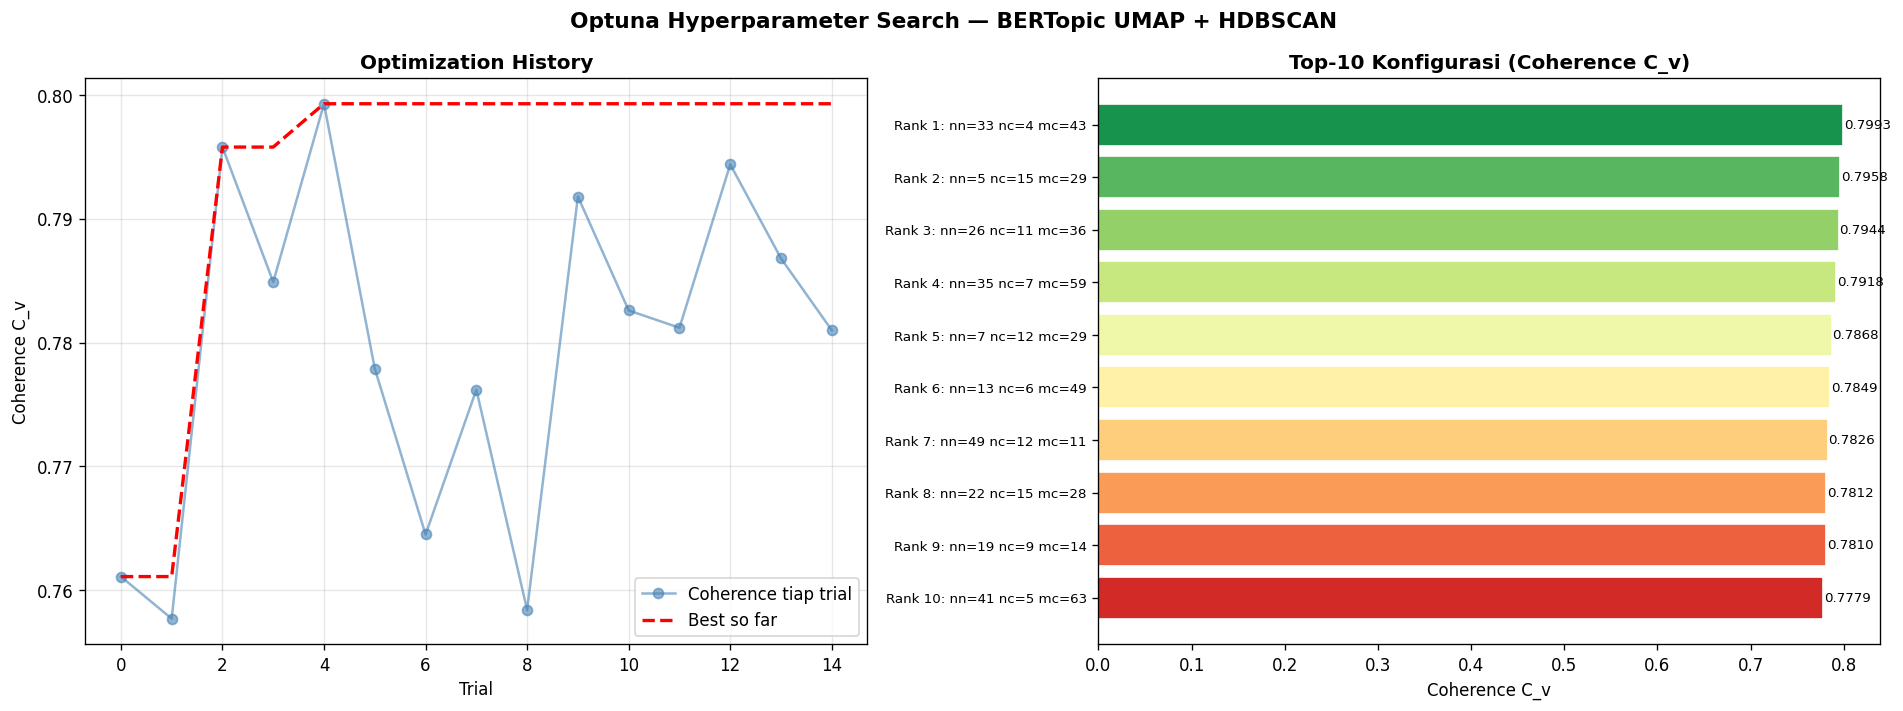

In [11]:
# Plot 1: Optimization history + Top-10 ranking
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Optuna Hyperparameter Search — BERTopic UMAP + HDBSCAN', fontweight='bold', fontsize=13)

trial_nums  = [t.number for t in study.trials if t.value and t.value > 0]
trial_vals  = [t.value for t in study.trials if t.value and t.value > 0]
best_so_far = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

axes[0].plot(trial_nums, trial_vals, 'o-', color='steelblue', alpha=0.6, label='Coherence tiap trial')
axes[0].plot(trial_nums, best_so_far, 'r--', linewidth=2, label='Best so far')
axes[0].set_title('Optimization History', fontweight='bold')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Coherence C_v')
axes[0].legend()
axes[0].grid(alpha=0.3)

top10   = df_results.head(10)
colors  = sns.color_palette('RdYlGn', len(top10))
bars    = axes[1].barh(range(len(top10)), top10['coherence_cv'], color=colors[::-1], edgecolor='white')
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(
    [f"Rank {i+1}: nn={int(r['umap_n_neighbors'])} nc={int(r['umap_n_components'])} mc={int(r['hdbscan_min_cluster'])}"
     for i, (_, r) in enumerate(top10.iterrows())], fontsize=8
)
axes[1].invert_yaxis()
axes[1].set_title('Top-10 Konfigurasi (Coherence C_v)', fontweight='bold')
axes[1].set_xlabel('Coherence C_v')
for bar, val in zip(bars, top10['coherence_cv']):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_s3_01_optuna_history.png', bbox_inches='tight')
plt.show()

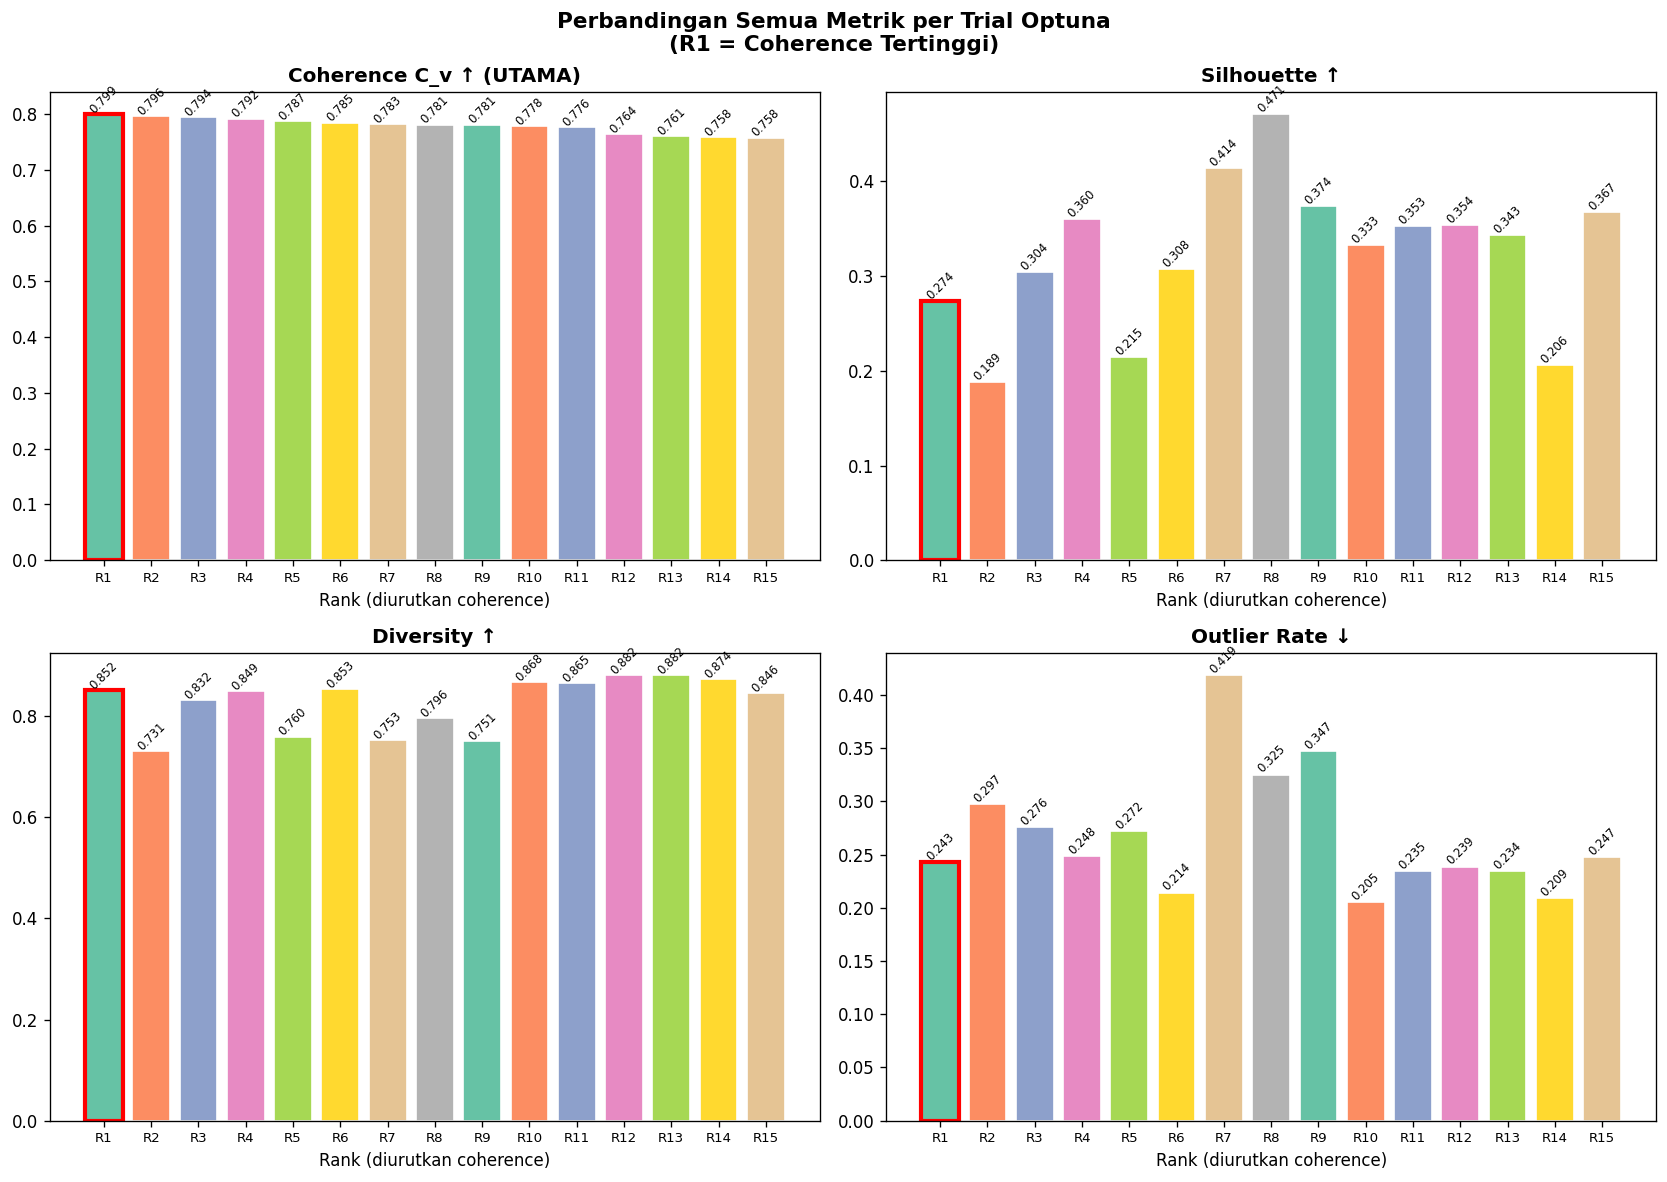

In [12]:
# Plot 2: Semua metrik per trial (diurutkan coherence)
metrics = ['coherence_cv', 'silhouette', 'diversity', 'outlier_rate']
titles  = ['Coherence C_v ↑ (UTAMA)', 'Silhouette ↑', 'Diversity ↑', 'Outlier Rate ↓']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perbandingan Semua Metrik per Trial Optuna\n(R1 = Coherence Tertinggi)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

colors = sns.color_palette('Set2', len(df_results))

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax   = axes[i]
    vals = df_results[metric]
    bars = ax.bar(range(len(df_results)), vals, color=colors, edgecolor='white')
    bars[0].set_edgecolor('red')
    bars[0].set_linewidth(2.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(len(df_results)))
    ax.set_xticklabels([f'R{j+1}' for j in range(len(df_results))], fontsize=8)
    ax.set_xlabel('Rank (diurutkan coherence)')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', fontsize=7, rotation=45)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_s3_02_semua_metrik.png', bbox_inches='tight')
plt.show()

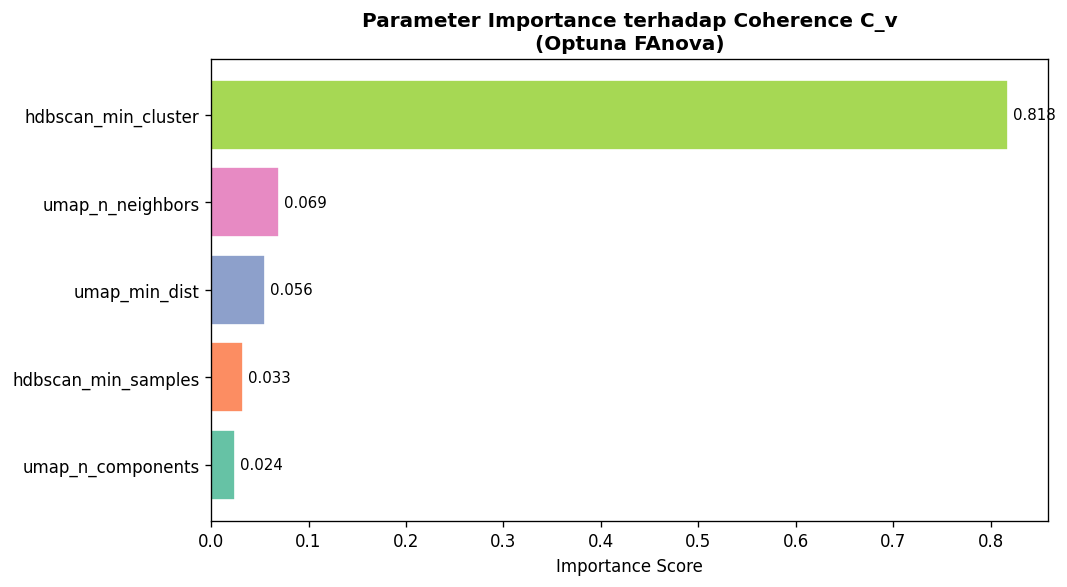

Parameter paling berpengaruh:
  hdbscan_min_cluster           : 0.8180
  umap_n_neighbors              : 0.0694
  umap_min_dist                 : 0.0555
  hdbscan_min_samples           : 0.0327
  umap_n_components             : 0.0244


In [13]:
# Plot 3: Parameter importance
try:
    importances = optuna.importance.get_param_importances(study)
    fig, ax = plt.subplots(figsize=(9, 5))
    params  = list(importances.keys())
    values  = list(importances.values())
    colors_imp = sns.color_palette('Set2', len(params))
    bars = ax.barh(params[::-1], values[::-1], color=colors_imp, edgecolor='white')
    for bar, val in zip(bars, values[::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_title('Parameter Importance terhadap Coherence C_v\n(Optuna FAnova)', fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/plot_s3_03_param_importance.png', bbox_inches='tight')
    plt.show()
    print('Parameter paling berpengaruh:')
    for p, v in importances.items():
        print(f'  {p:<30}: {v:.4f}')
except Exception as e:
    print(f'Parameter importance tidak tersedia: {e}')

---
## 8. Fit Model Terbaik & Visualisasi Topik

In [14]:
best = df_results.iloc[0]
print(f'Fitting model terbaik (coherence={best["coherence_cv"]})...')

best_model = BERTopic(
    umap_model = UMAP(
        n_neighbors  = int(best['umap_n_neighbors']),
        n_components = int(best['umap_n_components']),
        min_dist     = float(best['umap_min_dist']),
        metric       = 'cosine',
        random_state = 42
    ),
    hdbscan_model = HDBSCAN(
        min_cluster_size          = int(best['hdbscan_min_cluster']),
        min_samples               = int(best['hdbscan_min_samples']),
        cluster_selection_epsilon = 0.0,
        metric                    = 'euclidean',
        prediction_data           = True
    ),
    vectorizer_model = CountVectorizer(ngram_range=(1, 2), min_df=5),
    verbose          = True
)

topics_best, _ = best_model.fit_transform(docs, embeddings)
print(f'\n✅ Jumlah topik : {len(set(topics_best)) - 1}')
print(f'   Outlier      : {(np.array(topics_best)==-1).sum():,} ({(np.array(topics_best)==-1).mean():.1%})')

2026-06-12 14:13:07,573 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting model terbaik (coherence=0.7993)...


2026-06-12 14:13:37,442 - BERTopic - Dimensionality - Completed ✓
2026-06-12 14:13:37,445 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-12 14:13:38,116 - BERTopic - Cluster - Completed ✓
2026-06-12 14:13:38,124 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-12 14:13:45,659 - BERTopic - Representation - Completed ✓



✅ Jumlah topik : 71
   Outlier      : 4,791 (23.6%)


In [15]:
topic_info = best_model.get_topic_info()
print('=== TOP 10 TOPIK ===')
print(topic_info[topic_info['Topic'] != -1].head(10).to_string(index=False))
print('\n=== KATA-KATA PER TOPIK ===')
for tid in topic_info[topic_info['Topic'] != -1]['Topic'].head(10):
    words = [w for w, _ in best_model.get_topic(tid)[:8]]
    print(f'  Topik {tid:>3}: {", ".join(words)}')

=== TOP 10 TOPIK ===
 Topic  Count                                    Name                                                                                          Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

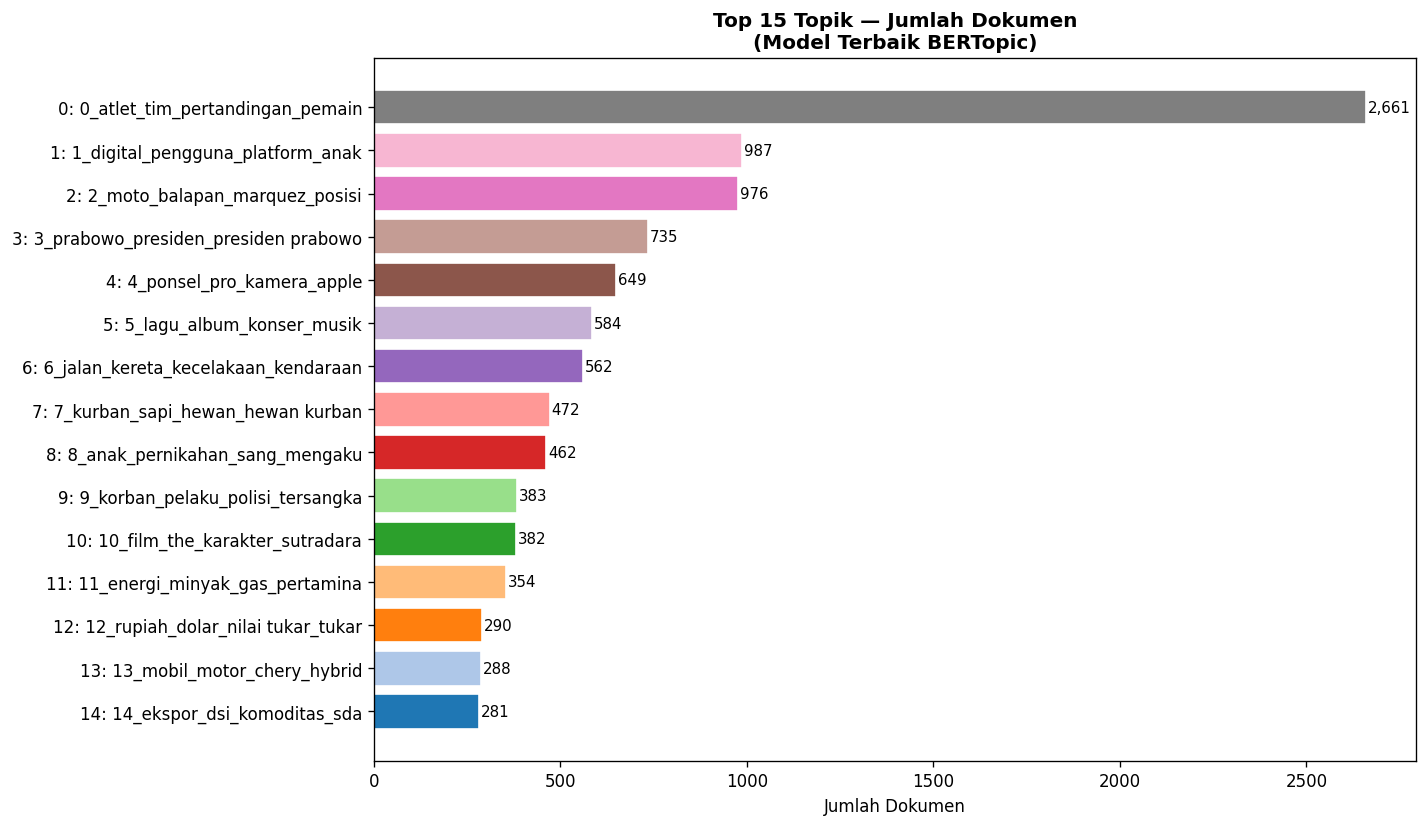

In [16]:
# Bar chart top 15 topik
topic_clean = topic_info[topic_info['Topic'] != -1].head(15).copy()
topic_clean['label'] = topic_clean['Topic'].astype(str) + ': ' + topic_clean['Name'].str[:35]

fig, ax = plt.subplots(figsize=(12, 7))
colors_t = sns.color_palette('tab20', len(topic_clean))
bars = ax.barh(topic_clean['label'][::-1], topic_clean['Count'][::-1], color=colors_t, edgecolor='white')
for bar, val in zip(bars, topic_clean['Count'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_title('Top 15 Topik — Jumlah Dokumen\n(Model Terbaik BERTopic)', fontweight='bold')
ax.set_xlabel('Jumlah Dokumen')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_s3_04_top_topik.png', bbox_inches='tight')
plt.show()

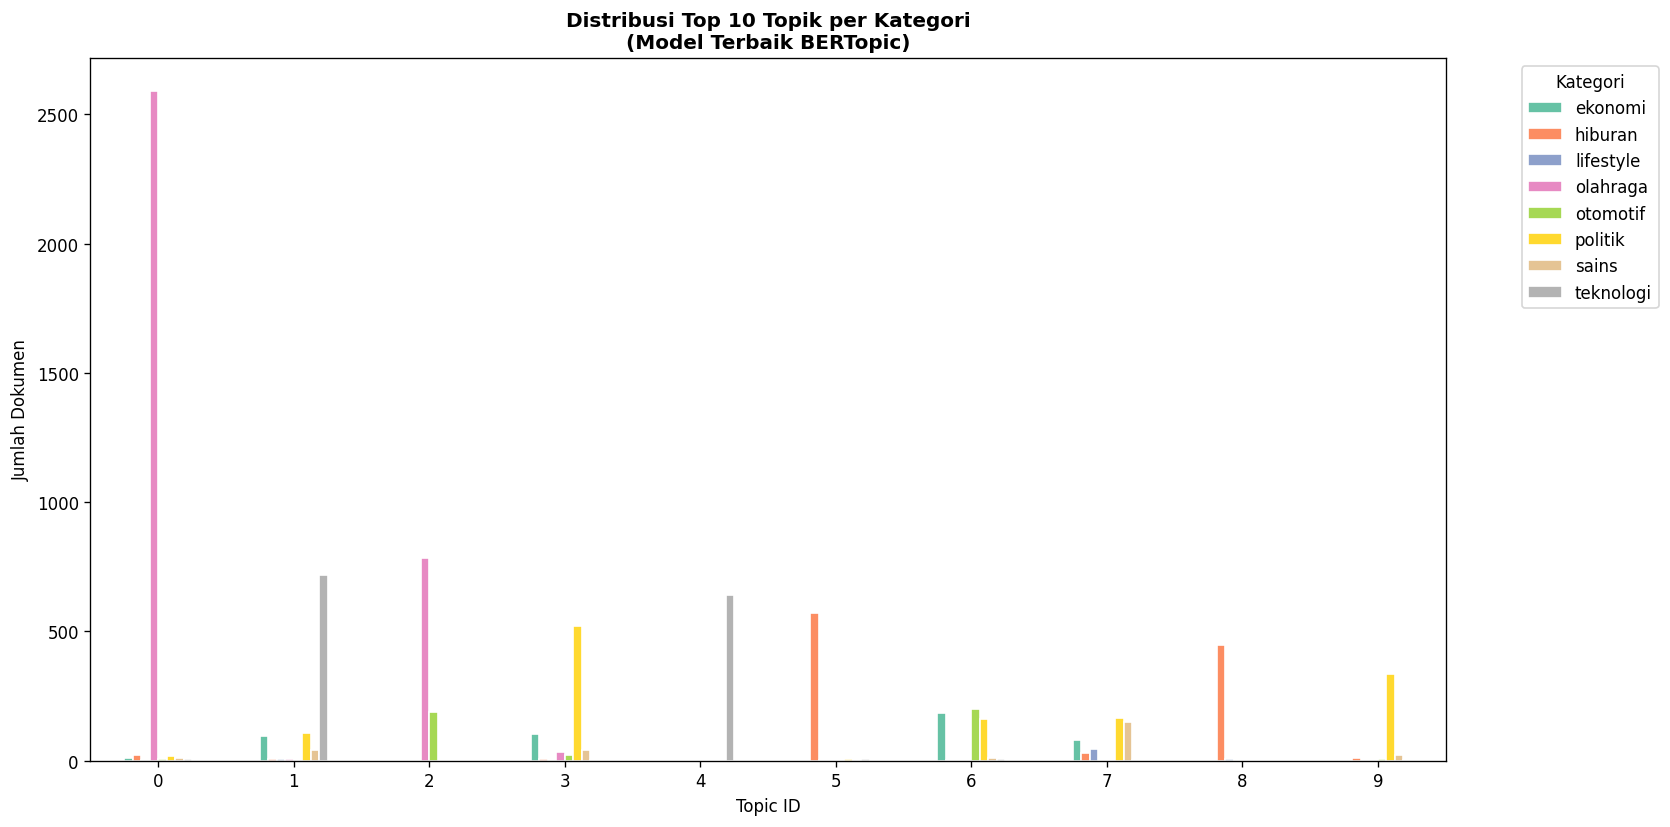

In [17]:
# Distribusi topik per kategori
df_hasil     = df_meta.copy()
df_hasil['topic'] = topics_best
top10_topics = topic_info[topic_info['Topic'] != -1]['Topic'].head(10).tolist()
df_vis       = df_hasil[df_hasil['topic'].isin(top10_topics)]
pivot_kat    = pd.crosstab(df_vis['topic'], df_vis['kategori'])

fig, ax = plt.subplots(figsize=(14, 7))
pivot_kat.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Distribusi Top 10 Topik per Kategori\n(Model Terbaik BERTopic)', fontweight='bold')
ax.set_xlabel('Topic ID')
ax.set_ylabel('Jumlah Dokumen')
ax.legend(title='Kategori', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_s3_05_topik_per_kategori.png', bbox_inches='tight')
plt.show()

In [18]:
fig_vis = best_model.visualize_topics()
fig_vis.write_html(f'{SAVE_DIR}/plot_s3_06_bertopic_interactive.html')
fig_vis.show()

fig_bar = best_model.visualize_barchart(top_n_topics=12)
fig_bar.write_html(f'{SAVE_DIR}/plot_s3_07_bertopic_barchart.html')
fig_bar.show()

---
## 9. Simpan Model & Hasil

In [19]:
best_model.save(f'{SAVE_DIR}/bertopic_best_final')
df_results.to_csv(f'{SAVE_DIR}/hasil_optuna_hyperparameter.csv', index_label='rank')
df_hasil.to_csv(f'{SAVE_DIR}/dokumen_dengan_topik.csv', index=False)

print('✅ bertopic_best_final')
print('✅ hasil_optuna_hyperparameter.csv')
print('✅ dokumen_dengan_topik.csv')

best = df_results.iloc[0]
print('\n' + '=' * 60)
print('RINGKASAN SKENARIO 2 — HYPERPARAMETER OPTUNA')
print('=' * 60)
print(f'Embedding model  : paraphrase-multilingual-MiniLM-L12-v2')
print(f'Optimizer        : Optuna TPE Sampler')
print(f'Trial dijalankan : {len([t for t in study.trials if t.value and t.value > 0])}')
print(f'Metrik utama     : Coherence C_v (maximize)')
print(f'\nKonfigurasi terbaik (coherence tertinggi):')
print(f'  UMAP  n_neighbors  : {int(best["umap_n_neighbors"])}')
print(f'  UMAP  n_components : {int(best["umap_n_components"])}')
print(f'  UMAP  min_dist     : {float(best["umap_min_dist"])}')
print(f'  HDBSCAN min_cluster: {int(best["hdbscan_min_cluster"])}')
print(f'  HDBSCAN min_samples: {int(best["hdbscan_min_samples"])}')
print(f'  Jumlah topik       : {int(best["n_topics"])}')
print(f'  Coherence C_v      : {best["coherence_cv"]}')
print(f'  Silhouette         : {best["silhouette"]}')
print(f'  Diversity          : {best["diversity"]}')
print(f'  Stability (top-5)  : {best["stability"]}')
print(f'  Outlier Rate       : {best["outlier_rate"]:.2%}')
print('=' * 60)

2026-06-12 14:14:00,816 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


✅ bertopic_best_final
✅ hasil_optuna_hyperparameter.csv
✅ dokumen_dengan_topik.csv

RINGKASAN SKENARIO 2 — HYPERPARAMETER OPTUNA
Embedding model  : paraphrase-multilingual-MiniLM-L12-v2
Optimizer        : Optuna TPE Sampler
Trial dijalankan : 15
Metrik utama     : Coherence C_v (maximize)

Konfigurasi terbaik (coherence tertinggi):
  UMAP  n_neighbors  : 33
  UMAP  n_components : 4
  UMAP  min_dist     : 0.0292
  HDBSCAN min_cluster: 43
  HDBSCAN min_samples: 5
  Jumlah topik       : 73
  Coherence C_v      : 0.7993
  Silhouette         : 0.2741999924182892
  Diversity          : 0.8521
  Stability (top-5)  : 0.9488
  Outlier Rate       : 24.30%
